#Importation des bibliothèques

In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Chargement des donnees

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


#Exploration des données

In [ ]:
train_df.head()
train_df.shape
train_df.describe()
train_df.isnull().any() # Vérification des valeurs manquantes
train_df.dtypes


,0
id,int64
Sex,object
Age,int64
Height,float64
Weight,float64
Duration,float64
Heart_Rate,float64
Body_Temp,float64
Calories,float64


In [ ]:
train_df["Sex"].value_counts()


,count
Sex,
female,375721
male,374279


#Prétraitement des données

In [ ]:
train_df["Sex"] = train_df["Sex"].map({"male": 0, "female": 1})
test_df["Sex"] = test_df["Sex"].map({"male": 0, "female": 1})


In [ ]:
train_df.dtypes

,0
id,int64
Sex,int64
Age,int64
Height,float64
Weight,float64
Duration,float64
Heart_Rate,float64
Body_Temp,float64
Calories,float64


In [ ]:
# 1) Check target column quality
print("Calories dtype:", train_df["Calories"].dtype)
print("Calories NaNs:", train_df["Calories"].isnull().sum())
print("Calories min/max:", train_df["Calories"].min(), train_df["Calories"].max())

# 2) Minimal cleaning (only if needed): remove rows with missing target
train_df = train_df.dropna(subset=["Calories"]).copy()

# 3) Recreate y and log-target safely
y = train_df["Calories"].to_numpy(dtype=np.float64)

# If you want absolute safety (should not be necessary, but ok):
y = np.clip(y, 0, None)

y_log = np.log1p(y)

print("y NaNs:", np.isnan(y).sum(), "| y_log NaNs:", np.isnan(y_log).sum())
print("y_log min/max:", np.min(y_log), np.max(y_log))

Calories dtype: float64
Calories NaNs: 0
Calories min/max: 1.0 314.0
y NaNs: 0 | y_log NaNs: 0
y_log min/max: 0.6931471805599453 5.752572638825633


In [ ]:
#separating the target
y = train_df["Calories"]

#dropping the id and the target from train
X = train_df.drop(columns=["id", "Calories"])
X_test = test_df.drop(columns=["id"])


In [ ]:
#converting to numpy arrays
X = X.to_numpy()
y = y.to_numpy()
X_test = X_test.to_numpy()

#Séparation train

In [ ]:
 # reproducibility

np.random.seed(42)

n_samples = X.shape[0]
indices = np.random.permutation(n_samples)

split_index = int(0.8 * n_samples)

train_indices = indices[:split_index]
val_indices = indices[split_index:]

X_train = X[train_indices]
X_val = X[val_indices]

y_train = y[train_indices]
y_val = y[val_indices]


#Normalisation


In [ ]:
# normalization
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)


# Avoid division by zero if any feature has zero variance
X_std[X_std == 0] = 1.0

X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

In [ ]:
# transforming the target using log(1 + y)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)


In [ ]:
#checking the shapes
X_train.shape, y_train_log.shape
X_val.shape, y_val_log.shape


((150000, 7), (150000,))

In [ ]:
# convert feature matrices to tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)


In [ ]:
# convert target vectors to tensors

y_train_tensor = torch.tensor(y_train_log, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_log, dtype=torch.float32)

#verification

X_train_tensor.shape, y_train_tensor.shape
X_val_tensor.shape, y_val_tensor.shape



(torch.Size([150000, 7]), torch.Size([150000]))

# Modèle de régression



In [ ]:

torch.manual_seed(42)

n_features = X_train_tensor.shape[1]

# Linear regression
model = nn.Linear(n_features, 1)

# MSE on log1p(Calories)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def rmsle_logspace(y_log_pred: torch.Tensor, y_log_true: torch.Tensor) -> float:
    """
    RMSLE = RMSE(log1p(y_pred), log1p(y_true))
    Here, both inputs are already in log1p space.
    """
    return torch.sqrt(torch.mean((y_log_pred - y_log_true) ** 2)).item()


#Entraînement du modèle

In [ ]:
# Training loop (full-batch)
epochs = 20
for epoch in range(1, epochs + 1):
    model.train()

    # Forward (train)
    pred_train = model(X_train_tensor).squeeze(1)   # shape: (n_train,)
    loss = criterion(pred_train, y_train_tensor)    # both are (n_train,)

    # Backward + update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation RMSLE (in log-space, RMSLE = RMSE on log1p targets)
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_tensor).squeeze(1)   # shape: (n_val,)
        val_rmsle = torch.sqrt(torch.mean((pred_val - y_val_tensor) ** 2)).item()

    print(f"Epoch {epoch:02d} | Train MSE(log) = {loss.item():.6f} | Val RMSLE = {val_rmsle:.6f}")

Epoch 01 | Train MSE(log) = 16.749161 | Val RMSLE = 4.086334
Epoch 02 | Train MSE(log) = 16.734161 | Val RMSLE = 4.084509
Epoch 03 | Train MSE(log) = 16.719183 | Val RMSLE = 4.082687
Epoch 04 | Train MSE(log) = 16.704235 | Val RMSLE = 4.080867
Epoch 05 | Train MSE(log) = 16.689310 | Val RMSLE = 4.079050
Epoch 06 | Train MSE(log) = 16.674410 | Val RMSLE = 4.077236
Epoch 07 | Train MSE(log) = 16.659538 | Val RMSLE = 4.075423
Epoch 08 | Train MSE(log) = 16.644697 | Val RMSLE = 4.073613
Epoch 09 | Train MSE(log) = 16.629877 | Val RMSLE = 4.071806
Epoch 10 | Train MSE(log) = 16.615088 | Val RMSLE = 4.070002
Epoch 11 | Train MSE(log) = 16.600323 | Val RMSLE = 4.068201
Epoch 12 | Train MSE(log) = 16.585592 | Val RMSLE = 4.066401
Epoch 13 | Train MSE(log) = 16.570885 | Val RMSLE = 4.064605
Epoch 14 | Train MSE(log) = 16.556210 | Val RMSLE = 4.062812
Epoch 15 | Train MSE(log) = 16.541563 | Val RMSLE = 4.061021
Epoch 16 | Train MSE(log) = 16.526943 | Val RMSLE = 4.059234
Epoch 17 | Train MSE(log

#Évaluation du modèle

In [ ]:
def rmsle_from_log_predictions(y_pred_log: torch.Tensor, y_true_log: torch.Tensor) -> float:
    """
    y_pred_log: model predictions in log1p space, shape (n,) or (n,1)
    y_true_log: true targets in log1p space, shape (n,) or (n,1)

    Returns: RMSLE as a Python float
    """
    # Ensure shape (n,)
    y_pred_log = y_pred_log.squeeze()
    y_true_log = y_true_log.squeeze()

    # Convert back to calories: y = exp(log1p(y)) - 1
    y_pred = torch.expm1(y_pred_log)
    y_true = torch.expm1(y_true_log)

    # Calories must be non-negative
    y_pred = torch.clamp(y_pred, min=0.0)
    y_true = torch.clamp(y_true, min=0.0)

    # RMSLE = sqrt(mean((log1p(y_pred) - log1p(y_true))^2))
    diff = torch.log1p(y_pred) - torch.log1p(y_true)
    return torch.sqrt(torch.mean(diff ** 2)).item()


In [ ]:
model.eval()
with torch.no_grad():
    y_val_pred_log = model(X_val_tensor).squeeze(1)
    val_rmsle = rmsle_from_log_predictions(y_val_pred_log, y_val_tensor)

print("Validation RMSLE:", val_rmsle)


Validation RMSLE: 3.9876420497894287


In [ ]:
torch.sqrt(torch.mean((y_val_pred_log - y_val_tensor) ** 2))


tensor(4.0521)

#Modèle Neural Network : Modèle 1 réseau de neurones

In [ ]:

def train_and_evaluate(model, X_train, y_train, X_val, y_val, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()

        pred_train = model(X_train).squeeze(1)
        loss = criterion(pred_train, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val).squeeze(1)
            val_rmsle = torch.sqrt(torch.mean((pred_val - y_val) ** 2)).item()

        print(f"Epoch {epoch:02d} | Train MSE(log)={loss.item():.6f} | Val RMSLE={val_rmsle:.6f}")

    return val_rmsle


In [ ]:
class MLP1(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


#Entraînement du modèle MLP 1

In [ ]:
#training the model

torch.manual_seed(42)
mlp1 = MLP1(X_train_tensor.shape[1])

val_rmsle_mlp1 = train_and_evaluate(
    mlp1,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=30,
    lr=1e-3
)

print("Final Val RMSLE (MLP1):", val_rmsle_mlp1)


Epoch 01 | Train MSE(log)=19.115417 | Val RMSLE=4.362474
Epoch 02 | Train MSE(log)=19.064489 | Val RMSLE=4.356653
Epoch 03 | Train MSE(log)=19.013809 | Val RMSLE=4.350853
Epoch 04 | Train MSE(log)=18.963377 | Val RMSLE=4.345074
Epoch 05 | Train MSE(log)=18.913193 | Val RMSLE=4.339316
Epoch 06 | Train MSE(log)=18.863258 | Val RMSLE=4.333580
Epoch 07 | Train MSE(log)=18.813574 | Val RMSLE=4.327864
Epoch 08 | Train MSE(log)=18.764133 | Val RMSLE=4.322169
Epoch 09 | Train MSE(log)=18.714939 | Val RMSLE=4.316495
Epoch 10 | Train MSE(log)=18.665987 | Val RMSLE=4.310841
Epoch 11 | Train MSE(log)=18.617271 | Val RMSLE=4.305207
Epoch 12 | Train MSE(log)=18.568790 | Val RMSLE=4.299592
Epoch 13 | Train MSE(log)=18.520535 | Val RMSLE=4.293995
Epoch 14 | Train MSE(log)=18.472494 | Val RMSLE=4.288415
Epoch 15 | Train MSE(log)=18.424669 | Val RMSLE=4.282852
Epoch 16 | Train MSE(log)=18.377041 | Val RMSLE=4.277305
Epoch 17 | Train MSE(log)=18.329601 | Val RMSLE=4.271772
Epoch 18 | Train MSE(log)=18.28

#Modèle Neural Network : Modèle 1 réseau de neurones

In [ ]:
class MLP2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


#Entraînement du modèle MLP 2

In [ ]:
#train
torch.manual_seed(42)
mlp2 = MLP2(X_train_tensor.shape[1])

val_rmsle_mlp2 = train_and_evaluate(
    mlp2,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=30,
    lr=1e-3
)

print("Final Val RMSLE (MLP2):", val_rmsle_mlp2)


Epoch 01 | Train MSE(log)=18.589836 | Val RMSLE=4.296041
Epoch 02 | Train MSE(log)=18.486191 | Val RMSLE=4.284081
Epoch 03 | Train MSE(log)=18.383684 | Val RMSLE=4.272219
Epoch 04 | Train MSE(log)=18.282286 | Val RMSLE=4.260450
Epoch 05 | Train MSE(log)=18.181950 | Val RMSLE=4.248768
Epoch 06 | Train MSE(log)=18.082647 | Val RMSLE=4.237168
Epoch 07 | Train MSE(log)=17.984312 | Val RMSLE=4.225644
Epoch 08 | Train MSE(log)=17.886881 | Val RMSLE=4.214182
Epoch 09 | Train MSE(log)=17.790264 | Val RMSLE=4.202773
Epoch 10 | Train MSE(log)=17.694344 | Val RMSLE=4.191401
Epoch 11 | Train MSE(log)=17.598980 | Val RMSLE=4.180045
Epoch 12 | Train MSE(log)=17.503996 | Val RMSLE=4.168681
Epoch 13 | Train MSE(log)=17.409163 | Val RMSLE=4.157277
Epoch 14 | Train MSE(log)=17.314232 | Val RMSLE=4.145801
Epoch 15 | Train MSE(log)=17.218975 | Val RMSLE=4.134227
Epoch 16 | Train MSE(log)=17.123173 | Val RMSLE=4.122534
Epoch 17 | Train MSE(log)=17.026648 | Val RMSLE=4.110703
Epoch 18 | Train MSE(log)=16.92

la table de comparesion des trois modèles

In [ ]:
val_rmsle_linear = 3.9876420497894287  # replace with your exact value

print("Validation RMSLE comparison")
print("Linear:", val_rmsle_linear)
print("MLP1  :", val_rmsle_mlp1)
print("MLP2  :", val_rmsle_mlp2)


Validation RMSLE comparison
Linear: 3.9876420497894287
MLP1  : 4.200630187988281
MLP2  : 3.9367451667785645


In [ ]:
def train_with_history(model, X_train, y_train, X_val, y_val, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        pred_train = model(X_train).squeeze(1)
        train_loss = criterion(pred_train, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # ---- validation ----
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val).squeeze(1)
            val_rmsle = torch.sqrt(torch.mean((pred_val - y_val) ** 2))  # RMSLE if targets are log1p

        train_losses.append(train_loss.item())
        val_losses.append(val_rmsle.item())

        print(f"Epoch {epoch:02d} | Train MSE(log)={train_loss.item():.6f} | Val RMSLE={val_rmsle.item():.6f}")

    return train_losses, val_losses


In [ ]:
train_losses, val_losses = train_with_history(
    mlp2,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=30,
    lr=1e-3
)

print(len(train_losses), len(val_losses))


Epoch 01 | Train MSE(log)=15.529563 | Val RMSLE=3.922652
Epoch 02 | Train MSE(log)=15.418835 | Val RMSLE=3.908418
Epoch 03 | Train MSE(log)=15.307404 | Val RMSLE=3.894039
Epoch 04 | Train MSE(log)=15.195251 | Val RMSLE=3.879508
Epoch 05 | Train MSE(log)=15.082340 | Val RMSLE=3.864820
Epoch 06 | Train MSE(log)=14.968637 | Val RMSLE=3.849963
Epoch 07 | Train MSE(log)=14.854076 | Val RMSLE=3.834928
Epoch 08 | Train MSE(log)=14.738595 | Val RMSLE=3.819704
Epoch 09 | Train MSE(log)=14.622117 | Val RMSLE=3.804276
Epoch 10 | Train MSE(log)=14.504560 | Val RMSLE=3.788632
Epoch 11 | Train MSE(log)=14.385845 | Val RMSLE=3.772762
Epoch 12 | Train MSE(log)=14.265910 | Val RMSLE=3.756655
Epoch 13 | Train MSE(log)=14.144689 | Val RMSLE=3.740299
Epoch 14 | Train MSE(log)=14.022126 | Val RMSLE=3.723685
Epoch 15 | Train MSE(log)=13.898169 | Val RMSLE=3.706800
Epoch 16 | Train MSE(log)=13.772765 | Val RMSLE=3.689635
Epoch 17 | Train MSE(log)=13.645865 | Val RMSLE=3.672179
Epoch 18 | Train MSE(log)=13.51

#Courbe de perte
Les pertes d’entraînement (MSE sur la cible transformée) et de validation (RMSLE) sont représentées sur des échelles différentes, ce qui explique leur amplitude distincte.Les pertes d’entraînement (MSE sur la cible transformée) et de validation (RMSLE) sont représentées sur des échelles différentes, ce qui explique leur amplitude distincte.

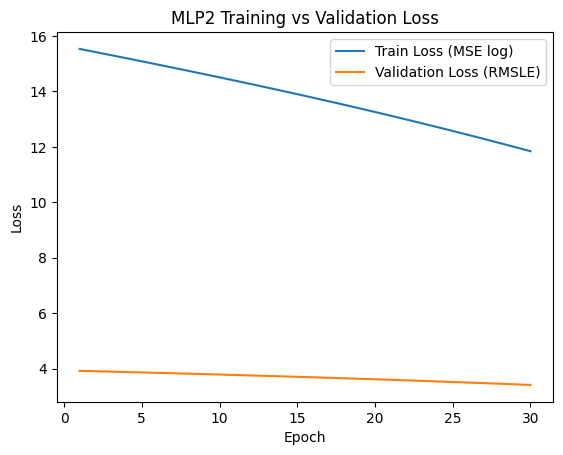

In [ ]:
# Epoch index
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss (MSE log)")
plt.plot(epochs, val_losses, label="Validation Loss (RMSLE)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP2 Training vs Validation Loss")
plt.legend()

plt.show()


#Bar chart comparing RMSLE

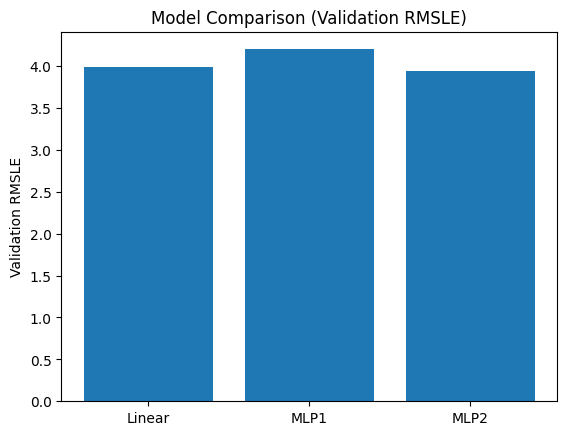

In [ ]:
val_rmsle_linear = 3.9876420497894287
val_rmsle_mlp1   = 4.200630187988281
val_rmsle_mlp2   = 3.9367451667785645

models = ["Linear", "MLP1", "MLP2"]
scores = [val_rmsle_linear, val_rmsle_mlp1, val_rmsle_mlp2]

plt.figure()
plt.bar(models, scores)
plt.ylabel("Validation RMSLE")
plt.title("Model Comparison (Validation RMSLE)")
plt.show()


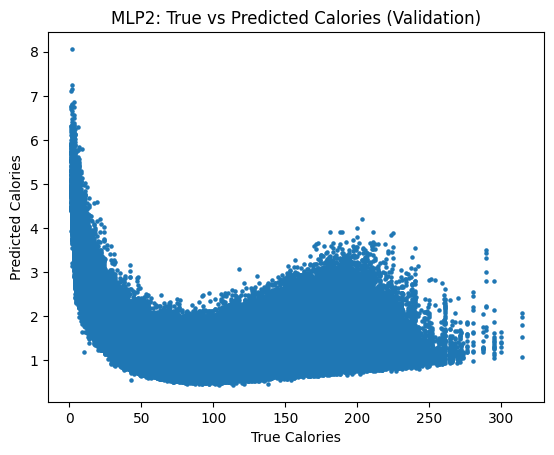

In [ ]:


mlp2.eval()
with torch.no_grad():
    pred_val_log = mlp2(X_val_tensor).squeeze(1)

# Convert back to Calories
y_val_true = torch.expm1(y_val_tensor).cpu().numpy()
y_val_pred = torch.expm1(pred_val_log).cpu().numpy()

# Clip negative predictions (physically impossible)
y_val_pred = np.clip(y_val_pred, 0, None)

plt.figure()
plt.scatter(y_val_true, y_val_pred, s=5)
plt.xlabel("True Calories")
plt.ylabel("Predicted Calories")
plt.title("MLP2: True vs Predicted Calories (Validation)")
plt.show()


In [ ]:

# --- Build full training set ---
train_df_clean = train_df.dropna(subset=["Calories"]).copy()

X_all_df = train_df_clean.drop(columns=["id", "Calories"])
y_all = train_df_clean["Calories"].to_numpy(dtype=np.float64)
y_all = np.clip(y_all, 0, None)
y_all_log = np.log1p(y_all)

X_all = X_all_df.to_numpy(dtype=np.float64)

# --- Build test features ---
X_test_df = test_df.drop(columns=["id"])
X_test = X_test_df.to_numpy(dtype=np.float64)

# --- Normalize using full training stats (fit on ALL train) ---
X_mean = X_all.mean(axis=0)
X_std  = X_all.std(axis=0) + 1e-8

X_all  = (X_all  - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# --- Convert to tensors ---
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all_log, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [ ]:

class MLP2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
final_model = MLP2(X_all_tensor.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)

epochs = 30
for epoch in range(1, epochs + 1):
    final_model.train()

    pred = final_model(X_all_tensor).squeeze(1)
    loss = criterion(pred, y_all_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Train MSE(log) = {loss.item():.6f}")

Epoch 05 | Train MSE(log) = 18.175407
Epoch 10 | Train MSE(log) = 17.687790
Epoch 15 | Train MSE(log) = 17.212423
Epoch 20 | Train MSE(log) = 16.724779
Epoch 25 | Train MSE(log) = 16.206165
Epoch 30 | Train MSE(log) = 15.642187


#Prédire la variable cible sur le jeu de test
# Création du fichier de soumission au format Kaggle

In [ ]:
final_model.eval()
with torch.no_grad():
    test_pred_log = final_model(X_test_tensor).squeeze(1)

# Convert back to Calories
test_pred = torch.expm1(test_pred_log).cpu().numpy()
test_pred = np.clip(test_pred, 0, None)


# Création du fichier de soumission au format Kaggle
submission = pd.DataFrame({
    "id": test_df["id"],
    "Calories": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()


,id,Calories
0,750000,0.383554
1,750001,0.513293
2,750002,0.232445
3,750003,0.215569
4,750004,0.268825
